# 01 Importing Libraries

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.cluster import KMeans
import pylab as pl
import scipy.stats as stats

# 02 Importing data and conducting necessary cleaning, manipulations, and reprocessing

In [43]:
# Set path
path = r'C:\Users\shaiv\Downloads\Victoria Airbnb Analysis\02 Data'

In [45]:
# Import data
vic_listings = pd.read_csv(os.path.join(path, 'Prepared Data', 'victoria_cleaned_2.csv'))

In [47]:
# Displaying maximum rows
pd.set_option('display.max_columns', None)

In [49]:
# Display 1st five rows
vic_listings.head()

,id,scrape_id,host_id,host_since,host_response_rate,host_acceptance_rate,host_is_superhost,host_identity_verified,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,listings_count,listings_count_home,listings_count_p_rooms,listings_count_s_rooms,reviews_per_month
0,83515,20241229042348,455118,2011-03-21,100.0,97.000000,1,1,Salt Spring Island,Salt Spring Island,48.86222,-123.49996,Entire guest suite,Entire home/apt,2,1.0,1.0,0.0,"[""Free parking on premises"", ""Dishes and silve...",175.0,2,730,1,8,23,44,289,2024-12-29,148,13,0,4.88,4.89,4.87,4.92,4.84,4.94,4.75,1,2.0,2,0,0,0.89
1,168460,20241229042348,802981,2011-07-10,100.0,87.101145,0,0,James Bay,Victoria,48.41620,-123.36790,Entire townhouse,Entire home/apt,3,2.5,2.0,2.0,"[""Free parking on premises"", ""Dishes and silve...",200.0,60,180,1,23,53,83,173,2024-12-29,64,0,0,4.91,4.90,4.98,4.89,4.92,5.00,4.90,0,1.0,1,0,0,0.42
2,185732,20241229042348,880366,2011-07-27,10.0,0.000000,0,1,Highlands,Highlands,48.50589,-123.46357,Private room in home,Private room,5,1.0,2.0,2.0,"[""Free parking on premises"", ""Hair dryer"", ""Sm...",199.0,1,365,1,30,60,90,365,2024-12-29,52,0,0,4.72,4.67,4.65,4.82,4.88,4.61,4.61,0,3.0,0,3,0,0.32
3,193366,20241229042348,937766,2011-08-07,75.0,100.000000,0,1,Rockland,Victoria,48.42574,-123.33760,Entire guest suite,Entire home/apt,6,2.0,2.0,3.0,"[""Free parking on premises"", ""Dishes and silve...",135.0,30,365,1,14,17,44,259,2024-12-29,157,1,0,4.75,4.83,4.78,4.92,4.89,4.88,4.76,1,1.0,1,0,0,1.00
4,201427,20241229042348,880366,2011-07-27,10.0,0.000000,0,1,Highlands,Highlands,48.50459,-123.46259,Private room in home,Private room,3,1.0,1.0,1.0,"[""Free parking on premises"", ""Indoor fireplace...",69.0,1,730,1,30,60,90,363,2024-12-29,51,0,0,4.63,4.80,4.78,4.96,5.00,4.58,4.68,0,3.0,0,3,0,0.34


In [51]:
# Check shape
vic_listings.shape

(3277, 44)

### Preprocessing data before clustering

In [54]:
# Removing extreme prices
vic_listings = vic_listings.loc[vic_listings['price'] <= 1000]

In [56]:
# Checking for highly correlated variables to avoid inaccurate clusttering
numeric_cols = vic_listings.select_dtypes(include=['number']).columns
corr_matrix = vic_listings[numeric_cols].corr()
print(corr_matrix)

                                   id  scrape_id   host_id  \
id                           1.000000        NaN  0.375464   
scrape_id                         NaN        NaN       NaN   
host_id                      0.375464        NaN  1.000000   
host_response_rate           0.019184        NaN -0.005665   
host_acceptance_rate        -0.000589        NaN  0.033805   
host_is_superhost           -0.144236        NaN -0.097188   
host_identity_verified      -0.112083        NaN -0.113593   
latitude                    -0.066767        NaN -0.016437   
longitude                    0.006916        NaN -0.055484   
accommodates                 0.051196        NaN  0.038600   
bathrooms                    0.040584        NaN -0.025717   
bedrooms                     0.056381        NaN  0.001915   
beds                        -0.010718        NaN  0.016069   
price                        0.013195        NaN -0.015276   
minimum_nights              -0.041402        NaN -0.095493   
maximum_

In [58]:
# Accommodates, bedrooms and beds have strong correlation, so will remove bedroom and beds from the dataframe
vic_listings[['accommodates', 'bedrooms', 'beds']].corr()

,accommodates,bedrooms,beds
accommodates,1.000000,0.806112,0.834823
bedrooms,0.806112,1.000000,0.732583
beds,0.834823,0.732583,1.000000


In [60]:
# Availability_30, availability_60 and availability_90 have strong correlation, we will remove availability_60 and availability_90 from the dataframe
vic_listings[['availability_30','availability_60','availability_90']].corr()

,availability_30,availability_60,availability_90
availability_30,1.000000,0.929716,0.861245
availability_60,0.929716,1.000000,0.962601
availability_90,0.861245,0.962601,1.000000


In [62]:
# Number_of_reviews_ltm and reviews_per_month have strong correlation, we will remove reviews_per_month from the dataframe
vic_listings[['number_of_reviews_ltm','reviews_per_month']].corr()

,number_of_reviews_ltm,reviews_per_month
number_of_reviews_ltm,1.000000,0.795374
reviews_per_month,0.795374,1.000000


In [64]:
# Review_scores_rating, review_scores_accuracy,review_scores_cleanliness, review_scores_checkin,review_scores_communication, review_scores_value have strong correlation, we will remove review_scores_accuracy,review_scores_cleanliness, review_scores_checkin,review_scores_communication, review_scores_value from the dataframe
vic_listings[['review_scores_rating', 'review_scores_accuracy','review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_value']].corr()

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_value
review_scores_rating,1.000000,0.849843,0.763952,0.720683,0.816118,0.822339
review_scores_accuracy,0.849843,1.000000,0.734679,0.717302,0.778008,0.757803
review_scores_cleanliness,0.763952,0.734679,1.000000,0.636427,0.649121,0.724681
review_scores_checkin,0.720683,0.717302,0.636427,1.000000,0.754162,0.659452
review_scores_communication,0.816118,0.778008,0.649121,0.754162,1.000000,0.727318
review_scores_value,0.822339,0.757803,0.724681,0.659452,0.727318,1.000000


In [66]:
# Listings_count and listings_count_home have stong correlation, we will remove listings_count_home from the dataframe
vic_listings[['listings_count','listings_count_home']].corr()

,listings_count,listings_count_home
listings_count,1.000000,0.934247
listings_count_home,0.934247,1.000000


In [68]:
# Selecting only numerical variable and removing strongly correlated variables to create a subset
sub = vic_listings[['host_response_rate','host_acceptance_rate','accommodates', 'bathrooms',
                    'price', 'minimum_nights', 'maximum_nights', 'availability_30', 'availability_365', 
                    'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d','review_scores_rating', 
                    'review_scores_location', 'listings_count','listings_count_p_rooms','listings_count_s_rooms']]
sub.head()

,host_response_rate,host_acceptance_rate,accommodates,bathrooms,price,minimum_nights,maximum_nights,availability_30,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_location,listings_count,listings_count_p_rooms,listings_count_s_rooms
0,100.0,97.000000,2,1.0,175.0,2,730,8,289,148,13,0,4.88,4.94,2.0,0,0
1,100.0,87.101145,3,2.5,200.0,60,180,23,173,64,0,0,4.91,5.00,1.0,0,0
2,10.0,0.000000,5,1.0,199.0,1,365,30,365,52,0,0,4.72,4.61,3.0,3,0
3,75.0,100.000000,6,2.0,135.0,30,365,14,259,157,1,0,4.75,4.88,1.0,0,0
4,10.0,0.000000,3,1.0,69.0,1,730,30,363,51,0,0,4.63,4.58,3.0,3,0


In [80]:
# Standardizing dataset
sub = stats.zscore(sub[['host_response_rate','host_acceptance_rate', 'accommodates', 'bathrooms', 
                              'price', 'minimum_nights', 'maximum_nights','availability_30', 'availability_365', 
                              'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d','review_scores_rating',  
                              'review_scores_location', 'listings_count','listings_count_p_rooms','listings_count_s_rooms']])

##### We have used z-score to normalize the data so that extreme values do not get higher weight.

# 03 Elbow technique

In [84]:
# Creating KMeans models for different clusters
num_cl = range(1, 10)
kmeans = [KMeans(n_clusters=i) for i in num_cl]

In [86]:
#Creating a score that represents a rate of variation for the given cluster option.
score = [kmeans[i].fit(sub).score(sub) for i in range(len(kmeans))] 
score

[-55709.000000000015,
 -52148.873740075396,
 -45964.99878016656,
 -42544.83676343718,
 -39224.06806832447,
 -36680.63070918072,
 -34467.95896977374,
 -32624.14729783364,
 -31974.069038483205]

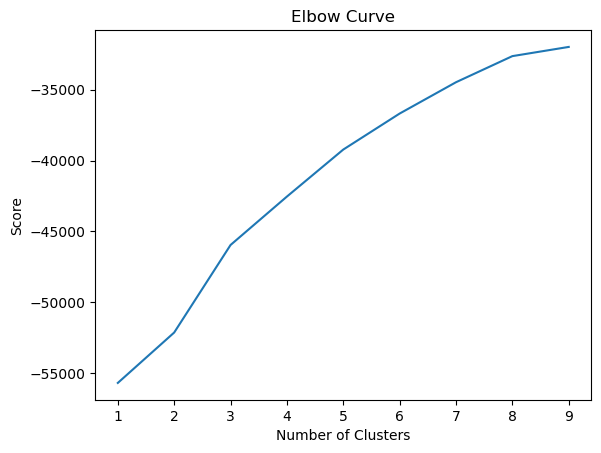

In [88]:
# Plotting the elbow curve using PyLab
pl.plot(num_cl,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

# 04 The curve starts to flatten at around 3 to 4 clusters. While the graph shows a noticeable jump from 5 to 6 clusters, selecting more clusters would reduce interpretability. I chose 4 clusters because the difference beyond this point is not significant enough to justify the added complexity in interpretation.

# 05 k-means algorithm

In [94]:
# k-means object
kmeans = KMeans(n_clusters = 5)

In [96]:
# Fitting the k-menas object to data
kmeans.fit(sub)

KMeans(n_clusters=5)

In [98]:
sub['clusters'] = kmeans.fit_predict(sub)
sub.head()

,host_response_rate,host_acceptance_rate,accommodates,bathrooms,price,minimum_nights,maximum_nights,availability_30,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_location,listings_count,listings_count_p_rooms,listings_count_s_rooms,clusters
0,0.226362,0.416657,-0.812084,-0.471375,-0.144915,-0.442794,0.713071,-0.677327,0.681798,0.777511,-0.132131,-0.474721,0.132766,0.381048,-0.327947,-0.251214,-0.092833,4
1,0.226362,-0.001046,-0.352861,1.908744,0.030191,1.691841,-0.565087,0.586346,-0.341142,-0.028709,-0.768814,-0.474721,0.253576,0.686439,-0.429046,-0.251214,-0.092833,4
2,-6.461794,-3.676457,0.565586,-0.471375,0.023186,-0.479598,-0.135161,1.176060,1.352000,-0.143883,-0.768814,-0.474721,-0.511555,-1.298605,-0.226848,0.599815,-0.092833,1
3,-1.631459,0.543248,1.024809,1.115371,-0.425085,0.587719,-0.135161,-0.171857,0.417244,0.863891,-0.719839,-0.474721,-0.390745,0.075656,-0.429046,-0.251214,-0.092833,4
4,-6.461794,-3.676457,-0.352861,-0.471375,-0.887366,-0.479598,0.713071,1.176060,1.334363,-0.153481,-0.768814,-0.474721,-0.873985,-1.451301,-0.226848,0.599815,-0.092833,1


In [100]:
sub['clusters'].value_counts()

clusters
4    1780
1     639
3     423
2     404
0      31
Name: count, dtype: int64

# 06 Adding clusters to main dataframe

In [102]:
vic_listings['clusters'] = sub['clusters']

In [104]:
# Verifying counts of clusters
vic_listings['clusters'].value_counts()

clusters
4    1780
1     639
3     423
2     404
0      31
Name: count, dtype: int64

# 07 and 08 Plot and Observations

C:\Users\shaiv\AppData\Local\Temp\ipykernel_10220\2264808377.py:3: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.scatterplot(x=vic_listings['listings_count'], y=vic_listings['price'], hue=kmeans.labels_, s=20, palette=sns.color_palette('deep'))


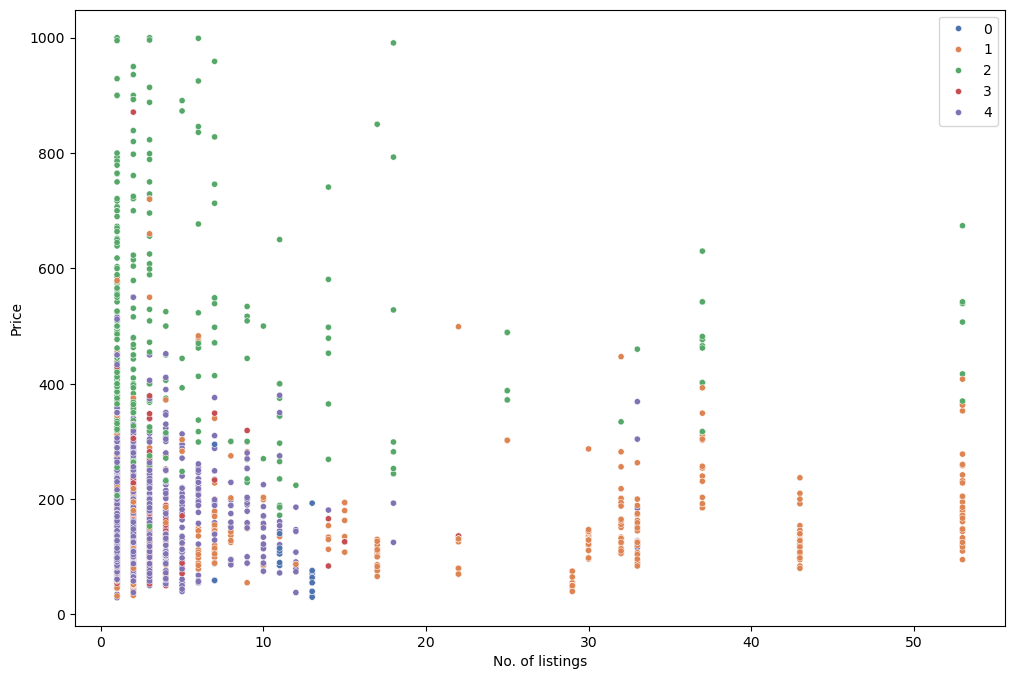

In [113]:
# Price vs no of listings plot
plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=vic_listings['listings_count'], y=vic_listings['price'], hue=kmeans.labels_, s=20, palette=sns.color_palette('deep')) 
ax.grid(False) 
plt.xlabel('No. of listings') 
plt.ylabel('Price') 
plt.show()

##### The purple cluster (Cluster 4) consists mostly of listings priced below 300, with fewer than 15 listings. Only a few listings exceed 300 or have more than 15 listings. The green cluster (Cluster 2) primarily includes listings priced above 300 with fewer than 20 listings, with only a few exceptions below 300 and above 20 listings. The orange cluster (Cluster 1) mostly consists of listings priced under 400.

C:\Users\shaiv\AppData\Local\Temp\ipykernel_10220\1588378432.py:3: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.scatterplot(x=vic_listings['review_scores_rating'], y=vic_listings['price'], hue=kmeans.labels_, s=20, palette=sns.color_palette('deep'))


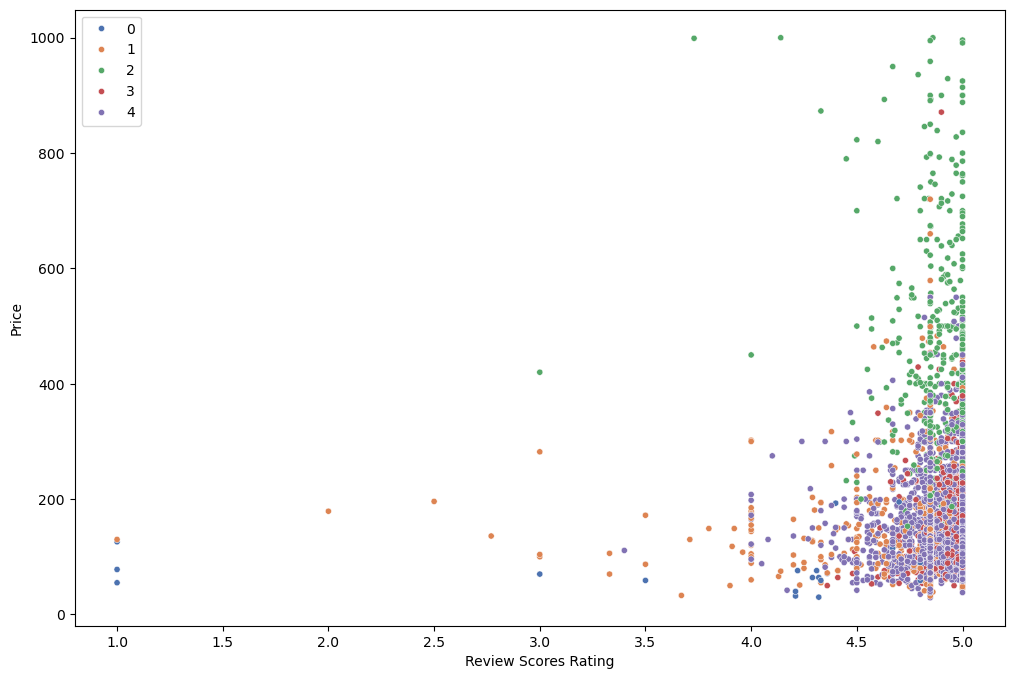

In [117]:
# Price vs review_score_rating plot
plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=vic_listings['review_scores_rating'], y=vic_listings['price'], hue=kmeans.labels_, s=20, palette=sns.color_palette('deep'))
ax.grid(False) 
plt.xlabel('Review Scores Rating') 
plt.ylabel('Price') 
plt.show()

##### All clusters have the majority of ratings above 4.0, with only a few instances falling below this threshold.

C:\Users\shaiv\AppData\Local\Temp\ipykernel_10220\1214352544.py:3: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.scatterplot(data = vic_listings, x = 'number_of_reviews', y = 'listings_count', hue=kmeans.labels_, s=20, palette=sns.color_palette('deep'))


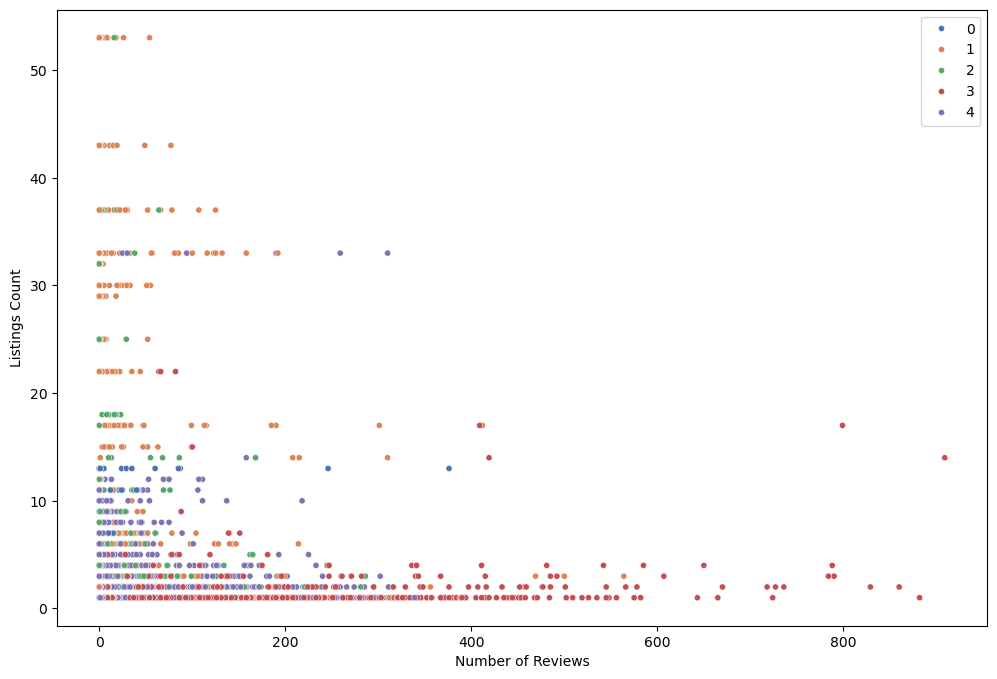

In [120]:
# Listings count vs no of reviews plot
plt.figure(figsize= (12,8))
ax = sns.scatterplot(data = vic_listings, x = 'number_of_reviews', y = 'listings_count', hue=kmeans.labels_, s=20, palette=sns.color_palette('deep'))
plt.xlabel('Number of Reviews')
plt.ylabel('Listings Count')
plt.show()

##### The red cluster (Cluster 3) has the highest number of reviews and a lower number of listings per host.

C:\Users\shaiv\AppData\Local\Temp\ipykernel_10220\1630072177.py:3: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.scatterplot(data = vic_listings, x = 'availability_30', y = 'price', hue=kmeans.labels_, s=20, palette=sns.color_palette('deep'))


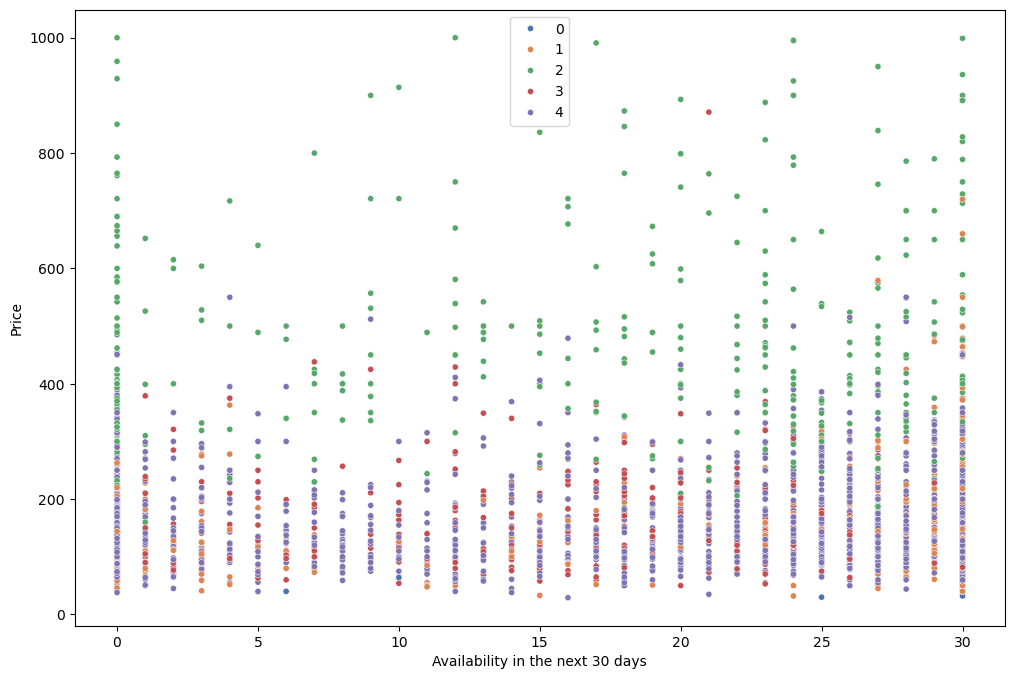

In [123]:
# Price vs availability_30 plot
plt.figure(figsize= (12,8))
ax = sns.scatterplot(data = vic_listings, x = 'availability_30', y = 'price', hue=kmeans.labels_, s=20, palette=sns.color_palette('deep'))
plt.xlabel('Availability in the next 30 days')
plt.ylabel('Price')
plt.show()

##### Highly priced (above 400) are occupied regularly, while the majority are not occupied in the next 30 days.

C:\Users\shaiv\AppData\Local\Temp\ipykernel_10220\1100395234.py:3: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.scatterplot(data = vic_listings, x = 'accommodates', y = 'price', hue=kmeans.labels_, s=20, palette=sns.color_palette('deep'))


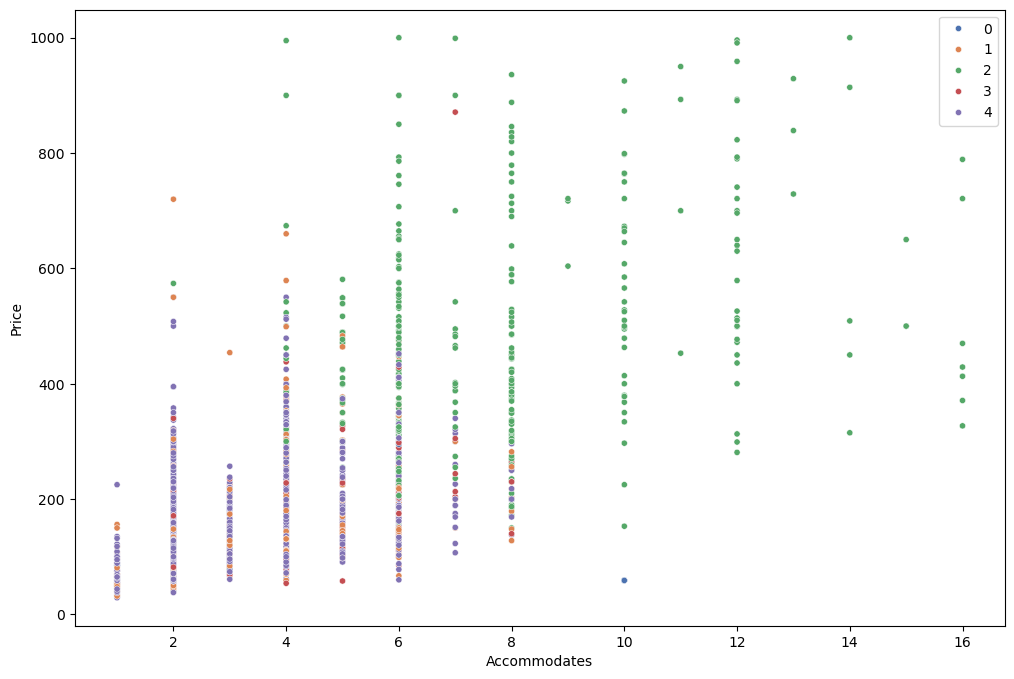

In [128]:
# Price vs accomodates plot
plt.figure(figsize= (12,8))
ax = sns.scatterplot(data = vic_listings, x = 'accommodates', y = 'price', hue=kmeans.labels_, s=20, palette=sns.color_palette('deep'))
plt.xlabel('Accommodates')
plt.ylabel('Price')
plt.show()

##### The green cluster (Cluster 2) accommodates more people than any other cluster and is priced higher than the listings in other clusters. These listings likely have a larger area.

In [131]:
# Adding clusters to original dataframe
vic_listings['cluster'] = sub['clusters']

In [133]:
vic_listings.loc[vic_listings['clusters'] == 0, 'cluster'] = 'blue'
vic_listings.loc[vic_listings['clusters'] == 1, 'cluster'] = 'yellow'
vic_listings.loc[vic_listings['clusters'] == 2, 'cluster'] = 'green'
vic_listings.loc[vic_listings['clusters'] == 3, 'cluster'] = 'red'
vic_listings.loc[vic_listings['clusters'] == 4, 'cluster'] = 'purple'

C:\Users\shaiv\AppData\Local\Temp\ipykernel_10220\1594135038.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'blue' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  vic_listings.loc[vic_listings['clusters'] == 0, 'cluster'] = 'blue'


# 09 Groupby clusters and looking at aggregations on various variables

In [136]:
vic_listings.groupby('cluster').agg({'price':['mean', 'median'], 'availability_30':['mean', 'median'], 'review_scores_rating':['mean', 'median'],
                          'listings_count':['mean', 'median'], 'number_of_reviews':['mean','median'], 'accommodates':['mean','median'],
                          'bathrooms':['mean','median'], 'minimum_nights':['mean','median'], 'maximum_nights':['mean','median']})

price        availability_30        review_scores_rating  \
               mean median            mean median                 mean   
cluster                                                                  
blue      88.548387   71.0        9.677419    0.0             4.176821   
green    466.858911  422.5       16.487624   20.0             4.871200   
purple   160.508989  142.0       15.635393   19.0             4.876147   
red      155.037825  135.0       15.347518   17.0             4.903995   
yellow   154.353678  130.0       17.651017   24.0             4.745452   

                  listings_count        number_of_reviews        accommodates  \
           median           mean median              mean median         mean   
cluster                                                                         
blue     4.670000      11.645161   11.0         36.935484   12.0     3.387097   
green    4.890000       6.121287    2.0         34.819307   17.0     7.522277   
purple   4.920000       2.130337    1.0         50.956742   29.0     3.140449   
red      4.930000       1.841608    1.0        225.250591  178.0     3.380615   
yellow   4.847149      15.303599    6.0         28.691706    5.0     3.419405   

               bathrooms        minimum_nights        maximum_nights         
        median      mean median           mean median           mean median  
cluster                                                                      
blue       2.0  1.032258   1.00      10.870968    1.0     477.419355  365.0  
green      6.5  2.518564   2.25       6.851485    2.0     404.116337  365.0  
purple     3.0  1.086236   1.00       7.730337    2.0     360.247753  180.0  
red        4.0  1.074468   1.00       3.905437    2.0     410.404255   90.0  
yellow     4.0  1.272300   1.00      42.978091   30.0     616.264476  365.0

##### The segmentation of listings by price reveals clear distinctions among clusters. The green cluster has the highest-priced listings (median 422.5), while the purple, red, and yellow clusters fall in the medium-price range (130–142 median). The blue cluster is the most affordable (median 71). Availability trends show that the yellow cluster has the highest availability (30 days median), while the red cluster has the lowest (2 days median), indicating higher demand. The purple and green clusters fall in between (~17–19 days median).

##### All clusters have average ratings above 4.0, reflecting overall positive guest feedback. However, the blue cluster has the lowest rating (4.18), while the red cluster has the highest (4.90), suggesting better guest experiences. The yellow cluster has the most listings per host (median 6), whereas the red and purple clusters are primarily managed by individual hosts (median 1 listing per host).

##### Review counts highlight that the red cluster has the highest number of reviews (median 178), suggesting high guest turnover, whereas the yellow cluster has fewer reviews despite high availability, possibly due to lower bookings or guest engagement. The green cluster accommodates the most people (median 6.5), suggesting larger properties, while the yellow and red clusters accommodate fewer guests (median ~4).

##### Most clusters offer 1-2 bathrooms on average, but the green cluster provides slightly more (median 2.25), aligning with its larger accommodations. Minimum stay requirements vary, with blue and yellow clusters requiring longer stays (median 10+ nights), whereas the purple and red clusters allow shorter stays (median 2 nights), possibly contributing to higher review counts. Maximum nights allowed is around a year in most clusters, except the red cluster, which has the shortest limit (median 90 nights), catering more to short-term travelers.

##### In summary, the green cluster consists of high-end, spacious listings, the red cluster features high-turnover, short-term rentals with excellent reviews, the purple cluster offers flexible, well-rated, mid-priced stays, the blue cluster provides budget-friendly options with lower ratings, and the yellow cluster consists of high-availability listings, often managed by hosts with multiple properties.

# 10 Future Steps

##### Given the availability trends observed, we can explore predicting the number of days a listing will be available in the next 30 days based on its price. This could also help in estimating potential revenue generation for each listing.

##### Since accommodation capacity influences price, we can leverage this relationship for price classification. While there isn’t a strong linear correlation, clustering helps in segmenting listings by accommodation size and pricing tiers.

In [143]:
# Exporting file
vic_listings.to_csv(os.path.join(path, 'Prepared Data', 'victoria_clean_clustered.csv'))